In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_ollama import ChatOllama
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,BaseMessage


In [ ]:
class state(TypedDict):

    message : Annotated[list[BaseMessage],add_messages]

In [20]:
model=ChatOllama(
    model='llama3.2:3b',
    reasoning=False
)
def chat(state:state):
    res=model.invoke(state['message'])
    return {'message': res}


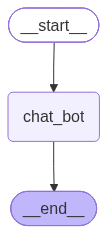

In [21]:
graph=StateGraph(state)

graph.add_node('chat_bot',chat)

graph.add_edge(START,'chat_bot')
graph.add_edge('chat_bot',END)

workflow=graph.compile()

workflow

In [22]:
intial_state={'message':[HumanMessage(content="what is the capital of india")]}
workflow.invoke(intial_state)

{'message': [HumanMessage(content='what is the capital of india', additional_kwargs={}, response_metadata={}, id='72bfa7ed-0a83-4297-88e2-fa8e8dd49faa'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-07-28T14:36:16.4113727Z', 'done': True, 'done_reason': 'stop', 'total_duration': 20550866400, 'load_duration': 20010597800, 'prompt_eval_count': 31, 'prompt_eval_duration': 237866000, 'eval_count': 9, 'eval_duration': 275011000, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019fa927-5848-7d63-8039-78d86024e312-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 31, 'output_tokens': 9, 'total_tokens': 40})]}

In [24]:
while True:
    user_input=input("enter the msg:")
    print("user :",user_input)
    if user_input.strip().lower() in ['braek','bye','exit']:
        break
    response=workflow.invoke({'message':[HumanMessage(content=user_input)]})
    print("ai :",response['message'][-1].content)

user : hi
ai : How can I assist you today?
user : what is the capital of brazil
ai : The capital of Brazil is Brasília.
user : who is the gandhi
ai : There have been several notable individuals named Gandhi throughout history, but I'll assume you're referring to Mahatma Gandhi (1869-1948), an Indian independence activist and leader.

Mahatma Gandhi was a key figure in India's struggle for independence from British rule. He is widely regarded as one of the most influential thinkers and leaders of the 20th century. Here's a brief overview of his life and philosophy:

**Early Life and Education**

Gandhi was born in Porbandar, Gujarat, India, to a devout Hindu family. He studied law at the University of Bombay (now Mumbai) and later became a barrister.

**Indian Independence Movement**

In 1915, Gandhi returned to India from South Africa, where he had lived for several years, and joined the Indian National Congress. He quickly emerged as a leading figure in the movement for Indian indepen